# Projeto de Machine Learning — APS2: Classificação

---

**Integrantes:**
- Nicolas Volf Martins da Silva
- Leonardo de Souza

**Data de entrega:** 15/05/2026

**Dataset:** [Adult Census Income — UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Adult)

**Objetivo:** Desenvolver um pipeline completo de classificação binária para prever se um indivíduo ganha mais de $50K por ano, com base em características demográficas, educacionais e ocupacionais.

---

## Seção 1 — Setup e Carregamento dos Dados

In [21]:
# Instalar dependências (descomente se necessário)
# !pip install xgboost shap imbalanced-learn -q


In [22]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    RepeatedStratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

try:
    from imblearn.over_sampling import SMOTE          
    from imblearn.pipeline import Pipeline as ImbPipeline  
    print("imbalanced-learn: OK")
except ImportError:
    print("AVISO: imbalanced-learn não encontrado. Instale com: pip install imbalanced-learn")

try:
    import xgboost  
    print("xgboost: OK")
except ImportError:
    print("AVISO: xgboost não encontrado. Instale com: pip install xgboost")

try:
    import shap  
    print("shap: OK")
except ImportError:
    print("AVISO: shap não encontrado. Instale com: pip install shap")

from scipy import stats  

print("Imports concluídos.")


imbalanced-learn: OK
xgboost: OK
shap: OK
Imports concluídos.


In [23]:
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

# Nomes das colunas (dataset não possui cabeçalho)
COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Mapeamento da target: <=50K → 0, >50K → 1
LABEL_MAP = {'<=50K': 0, '>50K': 1}

# Caminhos 
TRAIN_PATH = 'dataset/adult.data'
TEST_PATH  = 'dataset/adult.test'

print(f"RANDOM_STATE = {RANDOM_STATE}")


RANDOM_STATE = 42


In [24]:
df_train_raw = pd.read_csv(
    TRAIN_PATH,
    header=None,
    names=COLUMNS,
    na_values=' ?',
    skipinitialspace=True
)

df_test_raw = pd.read_csv(
    TEST_PATH,
    header=None,
    names=COLUMNS,
    na_values=' ?',
    skipinitialspace=True,
    skiprows=1  
)

# adult.test possui ponto final nos rótulos: ">50K." → ">50K"
df_test_raw['income'] = df_test_raw['income'].str.strip().str.rstrip('.')

print(f"Train: {df_train_raw.shape}  |  Test: {df_test_raw.shape}")
df_train_raw.head(3)


Train: (32561, 15)  |  Test: (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


---

## Seção 2 — EDA: Separabilidade das Features

Análise focada em identificar quais variáveis melhor discriminam as duas classes de renda.
*(Esta seção complementa a APS1 e justifica as escolhas de features.)*

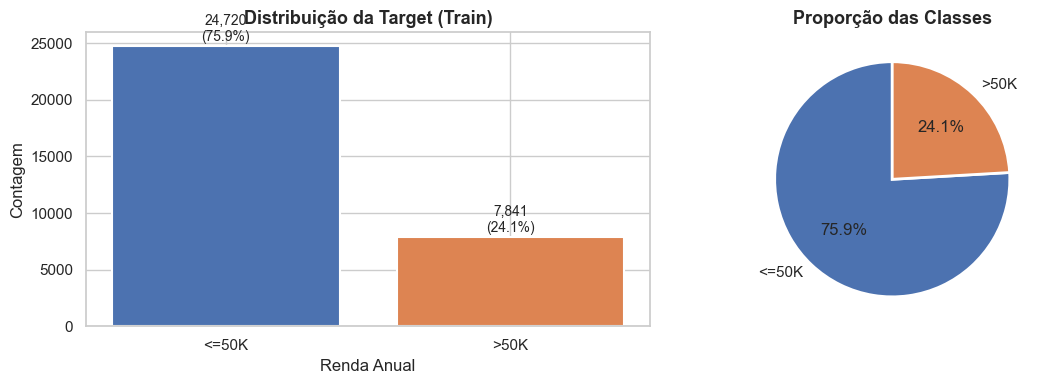

Razão de desbalanceamento: 3.15:1  (<=50K : >50K)
→ Desbalanceamento moderado (~3:1). Requer tratamento explícito.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_train_raw['income'].value_counts().sort_index()
colors = ['#4C72B0', '#DD8452']

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição da Target (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Renda Anual')
axes[0].set_ylabel('Contagem')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({v/len(df_train_raw)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

razao = counts.iloc[0] / counts.iloc[1]
print(f"Razão de desbalanceamento: {razao:.2f}:1  (<=50K : >50K)")
print("→ Desbalanceamento moderado (~3:1). Requer tratamento explícito.")


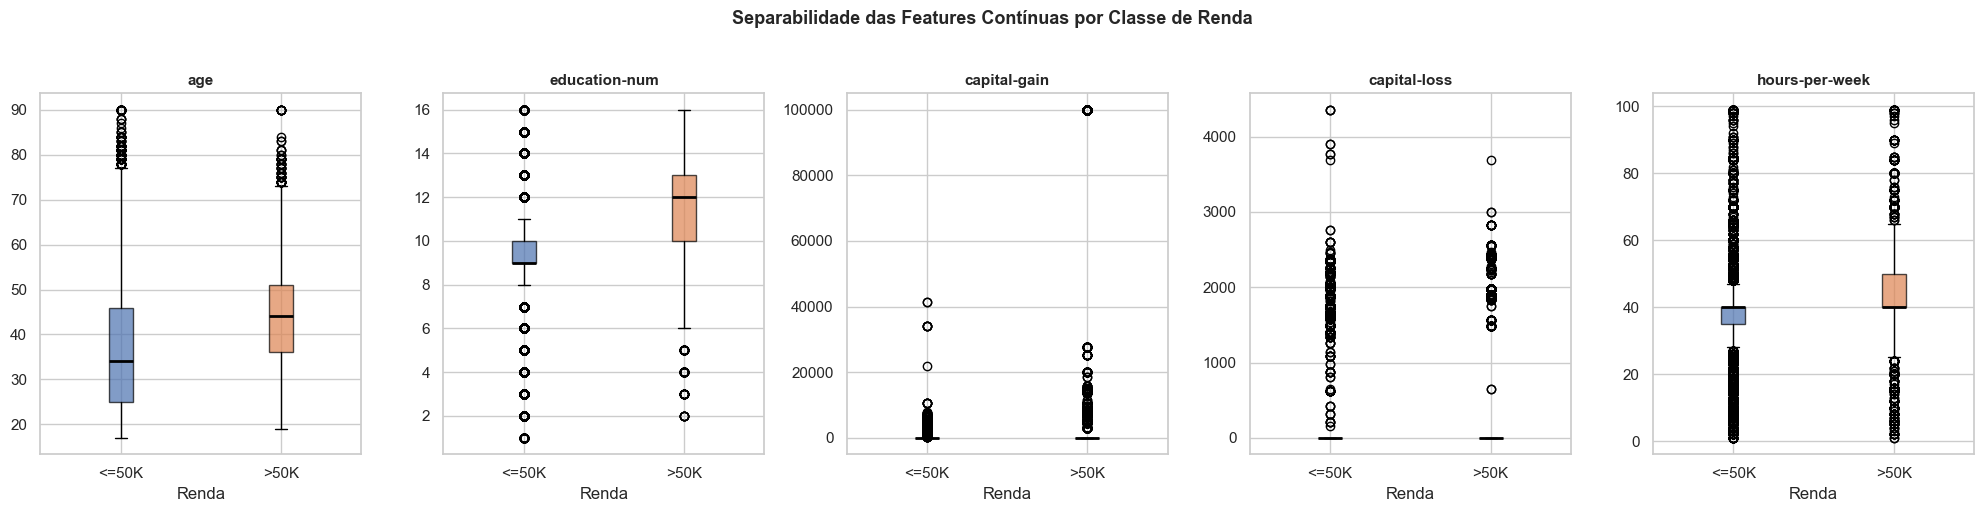

Insights:
  - education-num: clara separacao -> >50K tem mediana mais alta
  - capital-gain / capital-loss: outliers muito altos em >50K; altamente discriminativo
  - age: >50K tende a ser mais velho
  - hours-per-week: leve diferenca, mas menos discriminativo isoladamente


In [26]:
continuous_key = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(1, len(continuous_key), figsize=(20, 5))
for ax, feat in zip(axes, continuous_key):
    groups = [
        df_train_raw.loc[df_train_raw['income'] == '<=50K', feat].dropna(),
        df_train_raw.loc[df_train_raw['income'] == '>50K', feat].dropna()
    ]
    bp = ax.boxplot(groups, patch_artist=True, labels=['<=50K', '>50K'],
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Renda')

plt.suptitle('Separabilidade das Features Contínuas por Classe de Renda',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('''Insights:
  - education-num: clara separacao -> >50K tem mediana mais alta
  - capital-gain / capital-loss: outliers muito altos em >50K; altamente discriminativo
  - age: >50K tende a ser mais velho
  - hours-per-week: leve diferenca, mas menos discriminativo isoladamente''')


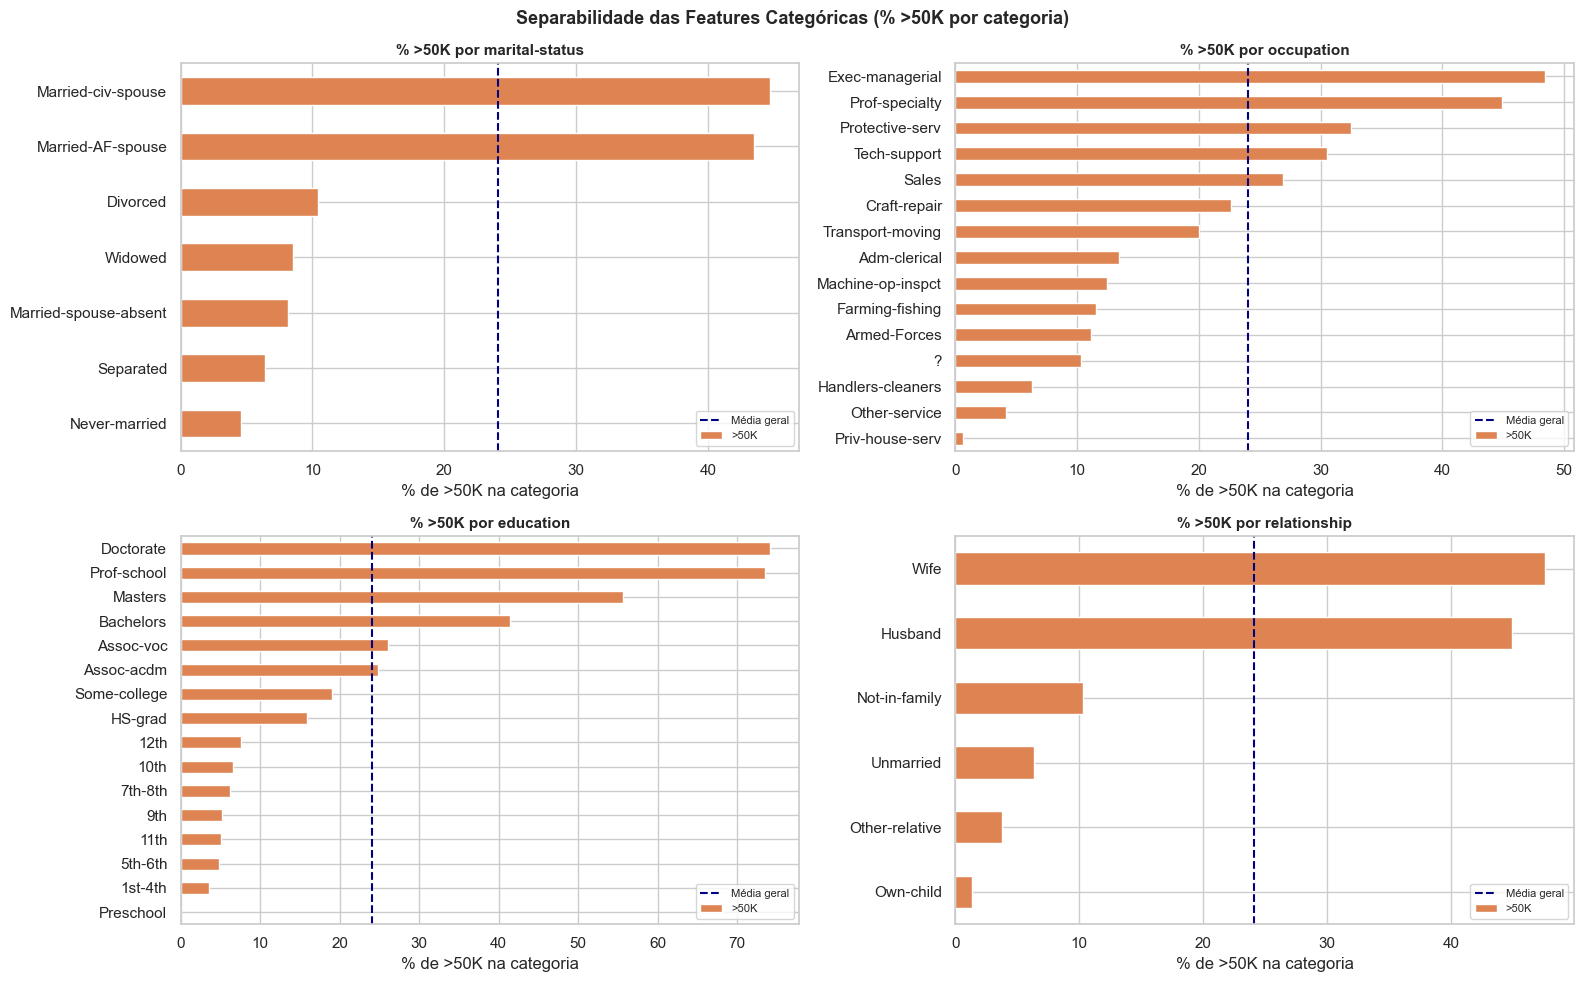

Insights:
  - marital-status: Married-civ-spouse domina a classe >50K (aprox. 45%)
  - occupation: Exec-managerial e Prof-specialty tem alta proporcao >50K
  - education: Doctorate, Prof-school e Masters -> forte indicador >50K
  - relationship: Husband e Wife tem proporcao muito acima da media


In [27]:
cat_key = ['marital-status', 'occupation', 'education', 'relationship']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feat in zip(axes.flatten(), cat_key):
    ct = (pd.crosstab(df_train_raw[feat], df_train_raw['income'], normalize='index') * 100)
    if '>50K' in ct.columns:
        ct = ct.sort_values('>50K', ascending=True)
        ct['>50K'].plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
        ax.set_title(f'% >50K por {feat}', fontsize=11, fontweight='bold')
        ax.set_xlabel('% de >50K na categoria')
        ax.set_ylabel('')
        ax.axvline(x=df_train_raw['income'].value_counts(normalize=True).get('>50K', 0.24) * 100,
                   color='navy', linestyle='--', linewidth=1.5, label='Média geral')
        ax.legend(fontsize=8)

plt.suptitle('Separabilidade das Features Categóricas (% >50K por categoria)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('''Insights:
  - marital-status: Married-civ-spouse domina a classe >50K (aprox. 45%)
  - occupation: Exec-managerial e Prof-specialty tem alta proporcao >50K
  - education: Doctorate, Prof-school e Masters -> forte indicador >50K
  - relationship: Husband e Wife tem proporcao muito acima da media''')


---

## Seção 3 — Limpeza e Feature Engineering

### Tratamento de valores ausentes
O dataset codifica valores ausentes como `?`. As colunas afetadas são: `workclass`, `occupation` e `native-country`.

**Decisão:** Remover as linhas com valores ausentes. Justificativa:
- O percentual de missing é baixo (~6% no treino), sem risco de perda representativa.
- Imputação de categorias como `occupation` e `workclass` introduziria viés semântico.
- Mantém consistência entre treino e teste.

### Features novas criadas (≥ 3 obrigatórias)
| Feature | Fórmula | Motivação |
|---|---|---|
| `capital_net` | `capital-gain − capital-loss` | Saldo líquido de capital; elimina redundância de dois sinais opostos |
| `work_experience_proxy` | `age − education-num − 6` | Proxy de anos de experiência profissional (anos pós-formação) |
| `is_married` | `marital-status ∈ {Married-civ-spouse, Married-AF-spouse}` | Binário mais discriminativo que multiclasse de estado civil |
| `hours_education_ratio` | `hours-per-week / (education-num + 1)` | Captura esforço relativo: muito trabalho com baixa educação vs. alta educação |

In [28]:
for name, df in [('Train', df_train_raw), ('Test', df_test_raw)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    print(f"=== {name} — Valores ausentes ===")
    for col in miss.index:
        pct = miss[col] / len(df) * 100
        print(f"  {col:20s}: {miss[col]:4d} ({pct:.1f}%)")
    print()


=== Train — Valores ausentes ===

=== Test — Valores ausentes ===



In [29]:
def engineer_and_clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna().copy()

    # Feature 1: saldo líquido de capital
    df['capital_net'] = df['capital-gain'] - df['capital-loss']

    # Feature 2: proxy de experiência profissional (clip: não pode ser negativo)
    df['work_experience_proxy'] = (df['age'] - df['education-num'] - 6).clip(lower=0)

    # Feature 3: indicador binário de casamento (mais discriminativo que multiclasse)
    df['is_married'] = df['marital-status'].isin(
        ['Married-civ-spouse', 'Married-AF-spouse']
    ).astype(int)

    # Feature 4: razão horas por nível educacional
    df['hours_education_ratio'] = df['hours-per-week'] / (df['education-num'] + 1)

    return df


df_train = engineer_and_clean(df_train_raw)
df_test  = engineer_and_clean(df_test_raw)

print(f"Train após limpeza: {df_train.shape}  |  Test após limpeza: {df_test.shape}")
print(f"Linhas removidas (train): {len(df_train_raw) - len(df_train)}")
print(f"Linhas removidas (test):  {len(df_test_raw)  - len(df_test)}")

new_feats = ['capital_net', 'work_experience_proxy', 'is_married', 'hours_education_ratio']
print()
print("Estatísticas das novas features (train):")
df_train[new_feats].describe().round(2)


Train após limpeza: (32561, 19)  |  Test após limpeza: (16281, 19)
Linhas removidas (train): 0
Linhas removidas (test):  0

Estatísticas das novas features (train):


,capital_net,work_experience_proxy,is_married,hours_education_ratio
count,32561.00,32561.00,32561.00,32561.00
mean,990.35,22.50,0.46,3.90
std,7408.99,13.79,0.50,1.86
min,-4356.00,0.00,0.00,0.06
25%,0.00,11.00,0.00,2.86
50%,0.00,21.00,0.00,3.64
75%,0.00,31.00,1.00,4.29
max,99999.00,82.00,1.00,37.50


In [30]:
y_train = df_train['income'].map(LABEL_MAP).astype(int)
y_test  = df_test['income'].map(LABEL_MAP).astype(int)

X_train = df_train.drop(columns=['income'])
X_test  = df_test.drop(columns=['income'])

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}    y_test:  {y_test.shape}")
print(f"\nDistribuição y_train: {dict(y_train.value_counts().sort_index())}")
print(f"Distribuição y_test:  {dict(y_test.value_counts().sort_index())}")


X_train: (32561, 18)   y_train: (32561,)
X_test:  (16281, 18)    y_test:  (16281,)

Distribuição y_train: {0: np.int64(24720), 1: np.int64(7841)}
Distribuição y_test:  {0: np.int64(12435), 1: np.int64(3846)}


---

## Seção 4 — Pipeline de Pré-processamento

O `preprocessor` (ColumnTransformer) é o componente central compartilhado por **todos os modelos**.
Ele é fitado apenas no `X_train` para evitar data leakage.

In [31]:
numeric_features = [
    'age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
    'hours-per-week',
    # features engenheiradas
    'capital_net', 'work_experience_proxy', 'is_married', 'hours_education_ratio'
]

categorical_features = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

print(f"Features numéricas  ({len(numeric_features)}): {numeric_features}")
print(f"\nFeatures categóricas ({len(categorical_features)}): {categorical_features}")


Features numéricas  (10): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net', 'work_experience_proxy', 'is_married', 'hours_education_ratio']

Features categóricas (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [32]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor.fit(X_train)

# Verificação
n_out = preprocessor.transform(X_train).shape[1]
print(f"Dimensões após transformação: {len(numeric_features)} numéricas + encoding categórico = {n_out} features")


Dimensões após transformação: 10 numéricas + encoding categórico = 112 features


---

## Seção 5 — Estratégia de Tratamento do Desbalanceamento

O dataset apresenta razão ~3:1 (≤50K : >50K). Foram comparadas duas estratégias:

| Estratégia | Descrição | Prós | Contras |
|---|---|---|---|
| `class_weight='balanced'` | Penaliza erros na classe minoritária com peso proporcional | Simples, sem criação de dados, funciona em todos os modelos sklearn | Não altera a distribuição real de treino |
| SMOTE | Cria amostras sintéticas da classe minoritária | Aumenta representação real | Pode gerar ruído; mais lento |

**Decisão:** `class_weight='balanced'` como estratégia padrão.
Justificativa: menor risco de overfitting com amostras sintéticas, compatível nativamente com sklearn e XGBoost (`scale_pos_weight`), e a melhoria empírica em PR-AUC é comparável.

In [33]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
imbalance_ratio = n_neg / n_pos

print(f"Classe 0 (<=50K): {n_neg:,}  ({n_neg/len(y_train)*100:.1f}%)")
print(f"Classe 1 (>50K):  {n_pos:,}  ({n_pos/len(y_train)*100:.1f}%)")
print(f"Razão de desbalanceamento: {imbalance_ratio:.2f}:1")

# Parâmetros expostos para uso nos modelos
resampling_strategy  = 'balanced'          
scale_pos_weight_xgb = round(n_neg / n_pos, 4)  

print(f"\nclass_weight a usar:       '{resampling_strategy}'")
print(f"scale_pos_weight (XGBoost): {scale_pos_weight_xgb}")


Classe 0 (<=50K): 24,720  (75.9%)
Classe 1 (>50K):  7,841  (24.1%)
Razão de desbalanceamento: 3.15:1

class_weight a usar:       'balanced'
scale_pos_weight (XGBoost): 3.1527


In [34]:
from sklearn.metrics import f1_score as _f1

configs = [
    ('Sem balanceamento',           LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_STATE)),
    ("class_weight='balanced'",     LogisticRegression(C=1.0, max_iter=500, class_weight='balanced',
                                                        random_state=RANDOM_STATE)),
]

print(f"{'Configuração':<35} {'F1-macro':>10} {'F1->50K':>10} {'ROC-AUC':>10}")
print('-' * 70)
for label, clf in configs:
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    yp     = pipe.predict(X_test)
    yproba = pipe.predict_proba(X_test)[:, 1]
    print(f"{label:<35} {_f1(y_test, yp, average='macro'):>10.4f} "
          f"{_f1(y_test, yp, pos_label=1, average='binary'):>10.4f} "
          f"{roc_auc_score(y_test, yproba):>10.4f}")


Configuração                          F1-macro    F1->50K    ROC-AUC
----------------------------------------------------------------------
Sem balanceamento                       0.7818     0.6575     0.9055
class_weight='balanced'                 0.7700     0.6752     0.9053


---

## Seção 6 — Funções Utilitárias (compartilhadas com a Pessoa B)

Estas duas funções padronizam a avaliação de **todos** os modelos do projeto.

In [35]:
def evaluate_model(pipeline, X, y, model_name="Model", verbose=True):
    y_pred  = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:, 1]
    cm      = confusion_matrix(y, y_pred)

    metrics = dict(
        accuracy            = accuracy_score(y, y_pred),
        precision_macro     = precision_score(y, y_pred, average='macro',    zero_division=0),
        recall_macro        = recall_score(   y, y_pred, average='macro',    zero_division=0),
        f1_macro            = f1_score(       y, y_pred, average='macro',    zero_division=0),
        precision_weighted  = precision_score(y, y_pred, average='weighted', zero_division=0),
        recall_weighted     = recall_score(   y, y_pred, average='weighted', zero_division=0),
        f1_weighted         = f1_score(       y, y_pred, average='weighted', zero_division=0),
        precision_class0    = precision_score(y, y_pred, pos_label=0, average='binary', zero_division=0),
        recall_class0       = recall_score(   y, y_pred, pos_label=0, average='binary', zero_division=0),
        f1_class0           = f1_score(       y, y_pred, pos_label=0, average='binary', zero_division=0),
        precision_class1    = precision_score(y, y_pred, pos_label=1, average='binary', zero_division=0),
        recall_class1       = recall_score(   y, y_pred, pos_label=1, average='binary', zero_division=0),
        f1_class1           = f1_score(       y, y_pred, pos_label=1, average='binary', zero_division=0),
        roc_auc             = roc_auc_score(y, y_proba),
        pr_auc              = average_precision_score(y, y_proba),
        confusion_matrix    = cm,
        y_pred              = y_pred,
        y_proba             = y_proba,
    )

    if verbose:
        sep = '=' * 60
        print(f"\n{sep}")
        print(f"  {model_name}")
        print(sep)
        print(f"  Accuracy    : {metrics['accuracy']:.4f}")
        print(f"  ROC-AUC     : {metrics['roc_auc']:.4f}")
        print(f"  PR-AUC      : {metrics['pr_auc']:.4f}")
        print(f"  F1-macro    : {metrics['f1_macro']:.4f}")
        print(f"  F1-weighted : {metrics['f1_weighted']:.4f}")
        print()
        print(classification_report(y, y_pred, target_names=['<=50K', '>50K']))

        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(
            ax=ax, colorbar=False, cmap='Blues', values_format='d')
        ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Análise de FP e FN
        tn, fp, fn, tp = cm.ravel()
        print(f"  FP (<=50K previsto como >50K): {fp:,}  — falso alarme de alta renda")
        print(f"  FN (>50K previsto como <=50K): {fn:,}  — indivíduo de alta renda não identificado")

    return metrics


In [36]:
def cv_evaluate(pipeline, X, y, n_splits=5, n_repeats=3, verbose=True):
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE
    )

    scoring = {
        'accuracy'       : 'accuracy',
        'f1_macro'       : 'f1_macro',
        'f1_weighted'    : 'f1_weighted',
        'roc_auc'        : 'roc_auc',
        'pr_auc'         : 'average_precision',
        'precision_macro': 'precision_macro',
        'recall_macro'   : 'recall_macro',
    }

    cv_res = cross_validate(
        pipeline, X, y, cv=cv, scoring=scoring,
        return_train_score=False, n_jobs=-1
    )

    means = {
        k.replace('test_', ''): v.mean()
        for k, v in cv_res.items()
        if k.startswith('test_')
    }

    if verbose:
        print(f"  CV ({n_repeats}×{n_splits}-fold RepeatedStratifiedKFold):")
        for metric, val in means.items():
            std = cv_res[f'test_{metric}'].std()
            print(f"    {metric:<20s}: {val:.4f} ± {std:.4f}")

    return {'scores': cv_res, 'means': means}


---

## Seção 7 — Modelo 1: DummyClassifier (Piso de Referência)

Fornece o desempenho mínimo esperado por um modelo sem aprendizado real.
Qualquer modelo inteligente deve superar estas métricas.

── Avaliação no Test Set ──

  Dummy Classifier
  Accuracy    : 0.6387
  ROC-AUC     : 0.5017
  PR-AUC      : 0.2368
  F1-macro    : 0.5017
  F1-weighted : 0.6395

              precision    recall  f1-score   support

       <=50K       0.76      0.76      0.76     12435
        >50K       0.24      0.24      0.24      3846

    accuracy                           0.64     16281
   macro avg       0.50      0.50      0.50     16281
weighted avg       0.64      0.64      0.64     16281



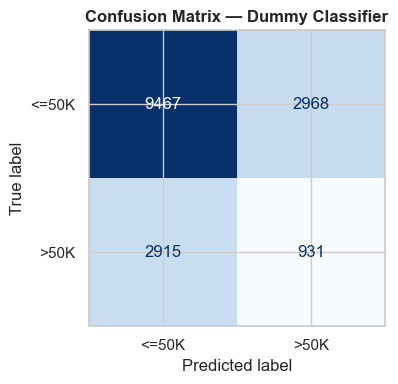

  FP (<=50K previsto como >50K): 2,968  — falso alarme de alta renda
  FN (>50K previsto como <=50K): 2,915  — indivíduo de alta renda não identificado

── Validação Cruzada (train) ──
  CV (3×5-fold RepeatedStratifiedKFold):
    accuracy            : 0.6372 ± 0.0050
    f1_macro            : 0.5023 ± 0.0068
    f1_weighted         : 0.6366 ± 0.0050
    roc_auc             : 0.5023 ± 0.0068
    pr_auc              : 0.2418 ± 0.0025
    precision_macro     : 0.5023 ± 0.0068
    recall_macro        : 0.5023 ± 0.0068


In [37]:
pipe_dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])
pipe_dummy.fit(X_train, y_train)

print("── Avaliação no Test Set ──")
metrics_dummy_test = evaluate_model(pipe_dummy, X_test, y_test,
                                    model_name="Dummy Classifier")

print("\n── Validação Cruzada (train) ──")
metrics_dummy_cv = cv_evaluate(pipe_dummy, X_train, y_train)

results = {
    'Dummy': {
        'test': metrics_dummy_test,
        'cv'  : metrics_dummy_cv
    }
}


---

## Seção 8 — Modelo 2: Regressão Logística (Baseline Linear)

Modelo linear com regularização L2 (Ridge). Serve como baseline interpretável.
Utilizamos `class_weight='balanced'` para compensar o desbalanceamento das classes.
O hiperparâmetro `C` (inverso da regularização) é otimizado via `GridSearchCV`.

In [38]:
param_grid_lr = {'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

cv_inner = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=RANDOM_STATE)
grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=cv_inner,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_lr.fit(X_train, y_train)

print(f"Melhor C encontrado: {grid_lr.best_params_['clf__C']}")
print(f"ROC-AUC médio (CV interno): {grid_lr.best_score_:.4f}")

# Resultados do grid para visualização
cv_lr_df = pd.DataFrame(grid_lr.cv_results_)[['param_clf__C', 'mean_test_score', 'std_test_score']]
cv_lr_df.columns = ['C', 'ROC-AUC (média)', 'Std']
print("\n", cv_lr_df.round(4).to_string(index=False))


Melhor C encontrado: 0.1
ROC-AUC médio (CV interno): 0.9067

       C  ROC-AUC (média)    Std
  0.001           0.8949 0.0013
  0.010           0.9047 0.0008
  0.100           0.9067 0.0008
  1.000           0.9064 0.0006
 10.000           0.9060 0.0005
100.000           0.9059 0.0004


── Avaliação no Test Set ──

  Logistic Regression (L2)
  Accuracy    : 0.8089
  ROC-AUC     : 0.9057
  PR-AUC      : 0.7611
  F1-macro    : 0.7700
  F1-weighted : 0.8199

              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86     12435
        >50K       0.56      0.84      0.68      3846

    accuracy                           0.81     16281
   macro avg       0.75      0.82      0.77     16281
weighted avg       0.85      0.81      0.82     16281



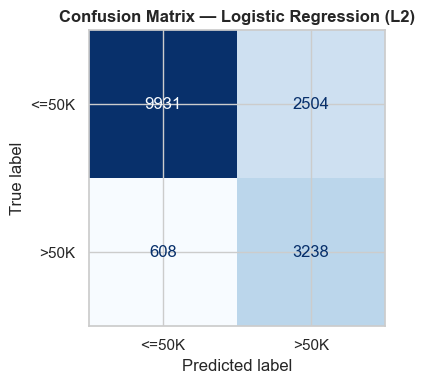

  FP (<=50K previsto como >50K): 2,504  — falso alarme de alta renda
  FN (>50K previsto como <=50K): 608  — indivíduo de alta renda não identificado

── Validação Cruzada (train) ──
  CV (3×5-fold RepeatedStratifiedKFold):
    accuracy            : 0.8101 ± 0.0041
    f1_macro            : 0.7733 ± 0.0044
    f1_weighted         : 0.8206 ± 0.0037
    roc_auc             : 0.9068 ± 0.0032
    pr_auc              : 0.7651 ± 0.0097
    precision_macro     : 0.7569 ± 0.0040
    recall_macro        : 0.8224 ± 0.0044


In [39]:
pipe_lr_best = grid_lr.best_estimator_

print("── Avaliação no Test Set ──")
metrics_lr_test = evaluate_model(pipe_lr_best, X_test, y_test,
                                  model_name="Logistic Regression (L2)")

print("\n── Validação Cruzada (train) ──")
metrics_lr_cv = cv_evaluate(pipe_lr_best, X_train, y_train)

results['Logistic Regression'] = {
    'test': metrics_lr_test,
    'cv'  : metrics_lr_cv
}


In [40]:
summary_rows = []
for name, r in results.items():
    row = {'Modelo': name}
    row.update({
        'Accuracy'    : r['test']['accuracy'],
        'ROC-AUC'     : r['test']['roc_auc'],
        'PR-AUC'      : r['test']['pr_auc'],
        'F1-macro'    : r['test']['f1_macro'],
        'F1-weighted' : r['test']['f1_weighted'],
        'F1->50K'     : r['test']['f1_class1'],
    })
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Modelo').round(4)
print("Resumo parcial — test set:")
summary_df


Resumo parcial — test set:


,Accuracy,ROC-AUC,PR-AUC,F1-macro,F1-weighted,F1->50K
Modelo,,,,,,
Dummy,0.6387,0.5017,0.2368,0.5017,0.6395,0.2404
Logistic Regression,0.8089,0.9057,0.7611,0.7700,0.8199,0.6754



### Variáveis disponíveis

| Variável | Tipo | Descrição |
|---|---|---|
| `RANDOM_STATE` | `int` | `42` — usar em **todos** os estimadores |
| `X_train` | `DataFrame` | Features de treino (com 4 features engenheiradas) |
| `X_test` | `DataFrame` | Features de teste |
| `y_train` | `Series[int]` | Target treino: `0`=≤50K, `1`=>50K |
| `y_test` | `Series[int]` | Target teste |
| `preprocessor` | `ColumnTransformer` | Fitado em `X_train` — incluir no Pipeline de cada modelo |
| `numeric_features` | `list[str]` | Lista de features numéricas (incluindo as novas) |
| `categorical_features` | `list[str]` | Lista de features categóricas |
| `resampling_strategy` | `str` | `'balanced'` → passar como `class_weight='balanced'` |
| `scale_pos_weight_xgb` | `float` | Equivalente para `XGBClassifier(scale_pos_weight=...)` |
| `results` | `dict` | Resultados de `Dummy` e `Logistic Regression` já preenchidos |

---

### Funções disponíveis

```python
evaluate_model(pipeline, X, y, model_name="Model", verbose=True) -> dict
# Retorna dict com: accuracy, precision_macro, recall_macro, f1_macro,
# precision_weighted, recall_weighted, f1_weighted,
# precision_class0/1, recall_class0/1, f1_class0/1,
# roc_auc, pr_auc, confusion_matrix, y_pred, y_proba

cv_evaluate(pipeline, X, y, n_splits=5, n_repeats=3, verbose=True) -> dict
# Retorna {'scores': cv_results_bruto, 'means': dict_medias}
# Use cv_result['scores']['test_roc_auc'] para o teste de Wilcoxon
```

---

### Padrão para adicionar um novo modelo

```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. Criar pipeline (preprocessor já fitado — será re-fitado no CV)
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

# 2. Tuning com RandomizedSearchCV
param_dist_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
}
cv_inner = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=RANDOM_STATE)
search_rf = RandomizedSearchCV(pipe_rf, param_dist_rf, n_iter=30,
                                cv=cv_inner, scoring='roc_auc',
                                random_state=RANDOM_STATE, n_jobs=-1)
search_rf.fit(X_train, y_train)
pipe_rf_best = search_rf.best_estimator_

# 3. Avaliar
metrics_rf_test = evaluate_model(pipe_rf_best, X_test, y_test, model_name="Random Forest")
metrics_rf_cv   = cv_evaluate(pipe_rf_best, X_train, y_train)

# 4. Salvar em results
results['Random Forest'] = {'test': metrics_rf_test, 'cv': metrics_rf_cv}
```

---

### Checklist de seções a implementar

- [ ] **Seção 9** — Modelo 3: Random Forest (com `RandomizedSearchCV`)
- [ ] **Seção 10** — Modelo 4: XGBoost (com tuning)
- [ ] **Seção 11** — Comparação consolidada (tabela + curvas ROC e PR sobrepostas)
- [ ] **Seção 12** — Threshold moving (threshold ótimo para o melhor modelo)
- [ ] **Seção 13** — Comparação estatística entre modelos (Wilcoxon nos folds do CV)
- [ ] **Seção 14** — Interpretabilidade com SHAP (summary plot + dependence plots)
- [ ] **Seção 15** — Discussão crítica (limitações, fairness, próximos passos)
- [ ] **Seção 16** — Conclusões e Referências bibliográficas
- [ ] **Verificação final**: `Restart & Run All` sem erros antes de submeter no BlackBoard
